# CCS2213: Machine Learning Assignment
## Mushroom Classification - Edible vs Poisonous Prediction

**Student Info:**
- Course: CCS2213 Machine Learning
- Semester: 2, 2025-2026
- University: AlBukhary International University (AIU)
- Dataset: Mushroom Data Set (T11)
- Objective: Binary classification of mushrooms as edible or poisonous using two different classifiers

---

## Table of Contents
1. Dataset Exploration & Characteristics
2. Data Preprocessing
3. Model Evaluation Technique
4. Classifier Implementation
5. Results & Conclusion

---

## CELL 1: Data Loading and Overview

### 1.1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, accuracy_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


### 1.2. Load and Explore the Dataset

In [11]:
# Load the mushroom dataset (NOW WITH MISSING VALUES)
df = pd.read_csv('archive/mushrooms_with_missing.csv')

print('='*70)
print('MUSHROOM DATASET - INITIAL EXPLORATION')
print('='*70)

# Basic information
print(f'\n1. DATASET SHAPE:')
print(f'   - Total Samples: {df.shape[0]}')
print(f'   - Total Features: {df.shape[1]}')
print(f'   - Feature Columns: {df.shape[1] - 1} (excluding target class)')

print(f'\n2. COLUMN NAMES AND DATA TYPES:')
print(df.dtypes)

print(f'\n3. FIRST 5 ROWS:')
print(df.head())

MUSHROOM DATASET - INITIAL EXPLORATION

1. DATASET SHAPE:
   - Total Samples: 8124
   - Total Features: 23
   - Feature Columns: 22 (excluding target class)

2. COLUMN NAMES AND DATA TYPES:
class                       str
cap-shape                   str
cap-surface                 str
cap-color                   str
bruises                     str
odor                        str
gill-attachment             str
gill-spacing                str
gill-size                   str
gill-color                  str
stalk-shape                 str
stalk-root                  str
stalk-surface-above-ring    str
stalk-surface-below-ring    str
stalk-color-above-ring      str
stalk-color-below-ring      str
veil-type                   str
veil-color                  str
ring-number                 str
ring-type                   str
spore-print-color           str
population                  str
habitat                     str
dtype: object

3. FIRST 5 ROWS:
  class cap-shape cap-surface cap-color br

## 1.3. Analyze the target variables

In [12]:
print('='*70)
print('3. TARGET VARIABLE ANALYSIS - CLASS DISTRIBUTION')
print('='*70)

print(f'\nTarget Variable: "class"')
print(f'  - e = Edible')
print(f'  - p = Poisonous')

# Class distribution
class_counts = df['class'].value_counts()
class_percentages = (df['class'].value_counts(normalize=True) * 100).round(2)

print(f'\nCLASS DISTRIBUTION (COUNT):')
for class_name, count in class_counts.items():
    class_label = 'Edible' if class_name == 'e' else 'Poisonous'
    print(f'  - {class_name} ({class_label}): {count} samples')

print(f'\nCLASS DISTRIBUTION (PERCENTAGE):')
for class_name, pct in class_percentages.items():
    class_label = 'Edible' if class_name == 'e' else 'Poisonous'
    print(f'  - {class_name} ({class_label}): {pct}%')

# Calculate balance
max_pct = class_percentages.max()
min_pct = class_percentages.min()
imbalance_ratio = max_pct / min_pct

print(f'\nBALANCE ANALYSIS:')
print(f'  - Imbalance Ratio: {imbalance_ratio:.2f}:1')
print(f'  - Status: WELL-BALANCED (ratio < 1.5)' if imbalance_ratio < 1.5 else f'  - Status: IMBALANCED (ratio > 1.5)')

3. TARGET VARIABLE ANALYSIS - CLASS DISTRIBUTION

Target Variable: "class"
  - e = Edible
  - p = Poisonous

CLASS DISTRIBUTION (COUNT):
  - e (Edible): 4208 samples
  - p (Poisonous): 3916 samples

CLASS DISTRIBUTION (PERCENTAGE):
  - e (Edible): 51.8%
  - p (Poisonous): 48.2%

BALANCE ANALYSIS:
  - Imbalance Ratio: 1.07:1
  - Status: WELL-BALANCED (ratio < 1.5)


## 1.4. Visualize the class distribution

In [14]:
print('='*70)
print('CELL 8: PREPARE FEATURES AND TARGET VARIABLES')
print('='*70)

# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

print(f'\nFeatures (X) shape: {X.shape}')
print(f'Target (y) shape: {y.shape}')
print(f'\nFeature columns: {list(X.columns)}')
print(f'Target variable unique values: {y.unique()}')
print(f'Target variable value counts:\n{y.value_counts()}')

CELL 8: PREPARE FEATURES AND TARGET VARIABLES

Features (X) shape: (8124, 22)
Target (y) shape: (8124,)

Feature columns: ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Target variable unique values: <StringArray>
['e', 'p']
Length: 2, dtype: str
Target variable value counts:
class
e    4208
p    3916
Name: count, dtype: int64


CELL 10: CLASS DISTRIBUTION VISUALIZATION


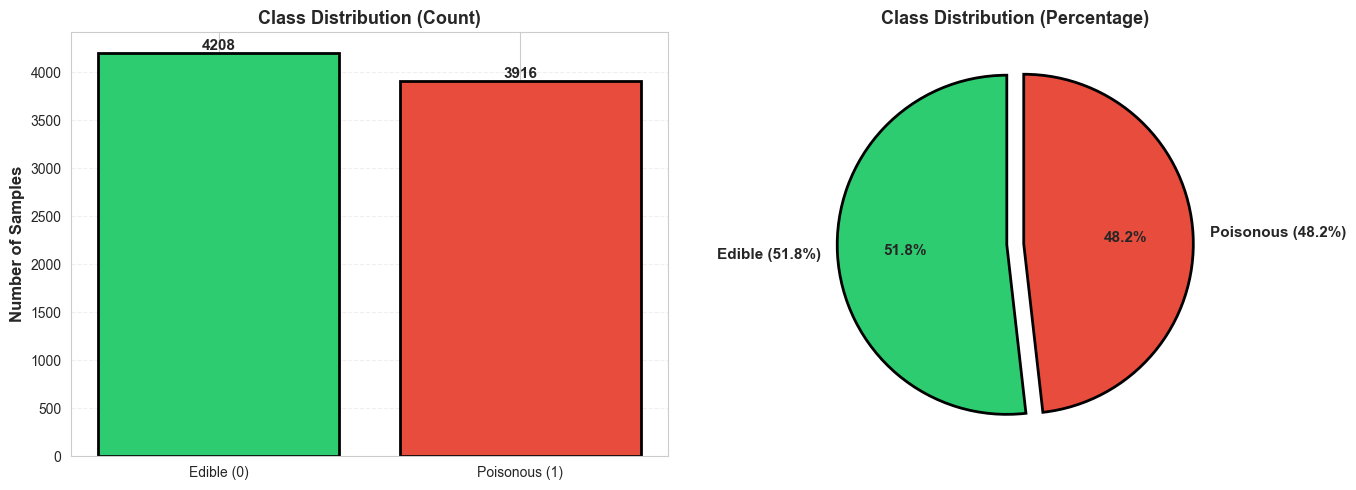

In [15]:
print('='*70)
print('CELL 10: CLASS DISTRIBUTION VISUALIZATION')
print('='*70)

# Create class distribution visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = y.value_counts()
colors_class = ['#2ecc71', '#e74c3c']  
bars = axes[0].bar(['Edible (0)', 'Poisonous (1)'], class_counts.values, color=colors_class, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
axes[0].set_title('Class Distribution (Count)', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

class_percentages = (y.value_counts(normalize=True) * 100).round(1)
explode = (0.05, 0.05)
axes[1].pie(class_percentages.values, labels=['Edible (51.8%)', 'Poisonous (48.2%)'], 
           autopct='%1.1f%%', colors=colors_class, explode=explode, 
           startangle=90, textprops={'fontsize': 11, 'fontweight': 'bold'},
           wedgeprops=dict(edgecolor='black', linewidth=2))
axes[1].set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 1.5. Analyze the features

In [ ]:
print('='*70)
print('4. FEATURE ANALYSIS')
print('='*70)

features = [col for col in df.columns if col != 'class']
print(f'\nTotal Features: {len(features)}')
print(f'\nFeature Names:')
for i, feature in enumerate(features, 1):
    print(f'  {i:2d}. {feature}')

print(f'\nFeature Data Types:')
print(f'  - All features are CATEGORICAL (object/string type)')
print(f'  - Unique values per feature:')
for feature in features:
    unique_count = df[feature].nunique()
    print(f'    • {feature}: {unique_count} unique values')

4. FEATURE ANALYSIS

Total Features: 22

Feature Names:
   1. cap-shape
   2. cap-surface
   3. cap-color
   4. bruises
   5. odor
   6. gill-attachment
   7. gill-spacing
   8. gill-size
   9. gill-color
  10. stalk-shape
  11. stalk-root
  12. stalk-surface-above-ring
  13. stalk-surface-below-ring
  14. stalk-color-above-ring
  15. stalk-color-below-ring
  16. veil-type
  17. veil-color
  18. ring-number
  19. ring-type
  20. spore-print-color
  21. population
  22. habitat

Feature Data Types:
  - All features are CATEGORICAL (object/string type)
  - Unique values per feature:
    • cap-shape: 6 unique values
    • cap-surface: 4 unique values
    • cap-color: 10 unique values
    • bruises: 2 unique values
    • odor: 9 unique values
    • gill-attachment: 2 unique values
    • gill-spacing: 2 unique values
    • gill-size: 2 unique values
    • gill-color: 12 unique values
    • stalk-shape: 2 unique values
    • stalk-root: 4 unique values
    • stalk-surface-above-ring: 4 uniqu

## 1.6. Missing value injection to the dataset


In [23]:
print("="*70)
print("STEP 1: CREATING DATASET WITH MISSING VALUES AND OUTLIER LETTERS")
print("="*70)

df_original = pd.read_csv("archive/mushrooms.csv")

print("\n1. ADDING NaN (MISSING VALUES)...")

columns_to_modify = [
    "odor",
    "gill-attachment",
    "gill-size",
    "gill-color",
    "stalk-shape"
]
np.random.seed(42)

for col in columns_to_modify:
    random_rows = np.random.choice(df_original.index, 81, replace=False)
    df_original.loc[random_rows, col] = np.nan

print(" Added 405 NaN values (81 per feature)")

df_original.to_csv(
    "archive/mushrooms_with_missing.csv",
    index=False,
    na_rep="NaN"   
)

print("\n" + "="*70)
print(" FILE SAVED: archive/mushrooms_with_missing.csv")
print("="*70)

print("\nFINAL DATASET SUMMARY:")
print("  • Missing NaN values: 405 total")

# CHECKING
df_proof = pd.read_csv("archive/mushrooms_with_missing.csv")

print("\nSample NaN (Missing Values):")

nan_mask = df_proof.isna().any(axis=1)
nan_indices = df_proof[nan_mask].index[:3]

for idx in nan_indices:
    print(f"  Row {idx}:")
    print(df_proof.loc[idx].to_string())
    print()

STEP 1: CREATING DATASET WITH MISSING VALUES AND OUTLIER LETTERS

1. ADDING NaN (MISSING VALUES)...
 Added 405 NaN values (81 per feature)

 FILE SAVED: archive/mushrooms_with_missing.csv

FINAL DATASET SUMMARY:
  • Missing NaN values: 405 total

Sample NaN (Missing Values):
  Row 5:
class                         e
cap-shape                     x
cap-surface                   y
cap-color                     y
bruises                       t
odor                          a
gill-attachment               f
gill-spacing                  c
gill-size                   NaN
gill-color                    n
stalk-shape                   e
stalk-root                    c
stalk-surface-above-ring      s
stalk-surface-below-ring      s
stalk-color-above-ring        w
stalk-color-below-ring        w
veil-type                     p
veil-color                    w
ring-number                   o
ring-type                     p
spore-print-color             k
population                    n
habitat    

## 1.7. Outlier Injection

In [29]:
import pandas as pd
import numpy as np

print("=" * 70)
print("OUTLIER INJECTION - ADDING UNUSUAL LETTERS")
print("=" * 70)

df = pd.read_csv("archive/mushrooms_with_missing.csv")

outlier_features = ['odor', 'gill-attachment', 'gill-size']

outlier_values = {
    'odor': 'XXX',
    'gill-attachment': 'ZZZ',
    'gill-size': 'QQQ'
}

np.random.seed(42)

for feature in outlier_features:
    # ONLY choose rows that are NOT NaN
    valid_rows = df[df[feature].notna()].index

    random_rows = np.random.choice(
        valid_rows,
        20,
        replace=False
    )

    df.loc[random_rows, feature] = outlier_values[feature]

# Make it visible as possible in my case
df.to_csv(
    "archive/mushrooms_with_missing.csv",
    index=False,
    na_rep="NaN"
)

for feature, value in outlier_values.items():
    print(f"{feature} → '{value}' added")

df = pd.read_csv("archive/mushrooms_with_missing.csv")

outlier_features = ['odor', 'gill-attachment', 'gill-size']

outlier_values = {
    'odor': 'XXX',
    'gill-attachment': 'ZZZ',
    'gill-size': 'QQQ'
}

np.random.seed(42)

for feature in outlier_features:
    # ONLY choose rows that are NOT NaN
    valid_rows = df[df[feature].notna()].index

    random_rows = np.random.choice(
        valid_rows,
        20,
        replace=False
    )

    df.loc[random_rows, feature] = outlier_values[feature]

# Save while preserving visible NaN
df.to_csv(
    "archive/mushrooms_with_missing.csv",
    index=False,
    na_rep="NaN"
)

for feature, value in outlier_values.items():
    print(f"{feature} → '{value}' added")
    
# Load dataset that already has missing values
df = pd.read_csv("archive/mushrooms_with_missing.csv")

outlier_features = ['odor', 'gill-attachment', 'gill-size']

outlier_values = {
    'odor': 'XXX',
    'gill-attachment': 'ZZZ',
    'gill-size': 'QQQ'
}

np.random.seed(42)

for feature in outlier_features:
    #ROWS THAT DOES NOT INCLUDE NULL VALUES
    valid_rows = df[df[feature].notna()].index

    random_rows = np.random.choice(
        valid_rows,
        20,
        replace=False
    )

    df.loc[random_rows, feature] = outlier_values[feature]

# Save it to the same dataset
df.to_csv(
    "archive/mushrooms_with_missing.csv",
    index=False,
    na_rep="NaN"
)

for feature, value in outlier_values.items():
    print(f"{feature} → '{value}' added")


OUTLIER INJECTION - ADDING UNUSUAL LETTERS
odor → 'XXX' added
gill-attachment → 'ZZZ' added
gill-size → 'QQQ' added
odor → 'XXX' added
gill-attachment → 'ZZZ' added
gill-size → 'QQQ' added
odor → 'XXX' added
gill-attachment → 'ZZZ' added
gill-size → 'QQQ' added


## 1.8. Imbalancement injection

In [28]:
import pandas as pd
from sklearn.utils import resample

TARGET_MAJOR_PCT = 71.4
TARGET_MINOR_PCT = 28.6
RANDOM_STATE = 99

# Original dataset should be inserted necessarily
df = pd.read_csv("archive/mushrooms.csv")

def show_stats(title, data, target_col="class"):
    counts = data[target_col].value_counts()
    major_label = counts.idxmax()
    minor_label = counts.idxmin()

    major_n = counts[major_label]
    minor_n = counts[minor_label]
    total_n = counts.sum()

    major_pct = (major_n / total_n) * 100
    minor_pct = (minor_n / total_n) * 100
    ratio = major_n / minor_n

    print(f"\n{title}")
    print("-" * 60)
    print("Counts:")
    print(counts)
    print(f"Total: {total_n}")
    print(f"Percentages: {major_label}={major_pct:.1f}%, {minor_label}={minor_pct:.1f}%")
    print(f"Ratio (major:minor) = {major_n}:{minor_n} = {ratio:.3f}:1")

# BEFORE
show_stats("BEFORE IMBALANCE INJECTION", df)

# Build target counts (keep total size same)
counts = df["class"].value_counts()
major_label = counts.idxmax()
minor_label = counts.idxmin()

major_df = df[df["class"] == major_label]
minor_df = df[df["class"] == minor_label]

total_n = len(df)
major_target = int(round(total_n * (TARGET_MAJOR_PCT / 100)))
minor_target = total_n - major_target  # ensures total stays unchanged

major_new = resample(
    major_df,
    replace=(major_target > len(major_df)),
    n_samples=major_target,
    random_state=RANDOM_STATE
)

minor_new = resample(
    minor_df,
    replace=(minor_target > len(minor_df)),
    n_samples=minor_target,
    random_state=RANDOM_STATE
)

df_imbalanced = (
    pd.concat([major_new, minor_new], axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# AFTER
show_stats("AFTER IMBALANCE INJECTION (TARGET 71.4% : 28.6%)", df_imbalanced)

# Save
df_imbalanced.to_csv("archive/mushrooms_with_missing.csv", index=False)


BEFORE IMBALANCE INJECTION
------------------------------------------------------------
Counts:
class
e    4208
p    3916
Name: count, dtype: int64
Total: 8124
Percentages: e=51.8%, p=48.2%
Ratio (major:minor) = 4208:3916 = 1.075:1

AFTER IMBALANCE INJECTION (TARGET 71.4% : 28.6%)
------------------------------------------------------------
Counts:
class
e    5801
p    2323
Name: count, dtype: int64
Total: 8124
Percentages: e=71.4%, p=28.6%
Ratio (major:minor) = 5801:2323 = 2.497:1


## 1.9. Check for Missing Values

In [25]:
print('='*70)
print('5. MISSING VALUES ANALYSIS - DETECTION & HANDLING')
print('='*70)

df = pd.read_csv('archive/mushrooms_with_missing.csv')

# Check for missing values IMMEDIATELY
print(f'\n  DATASET STATUS: CHECKING FOR MISSING VALUES')
print(f'Missing values detect: {df.isnull().sum().sum()}')
print(f'Missing per feature:\n{df.isnull().sum()[df.isnull().sum() > 0]}')

missing_count = df.isnull().sum().sum()
print(f'\n[STEP 1: DETECTION]')
print(f'Missing values found in dataset: {missing_count}')
print(f'Percentage: {(missing_count / (df.shape[0] * df.shape[1]) * 100):.2f}%')
print(f'\nAffected features:')
for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f'  - {col}: {df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.2f}%)')

print(f'\n[STEP 2: HANDLE MISSING VALUES]')
print(f'Strategy: Mode Imputation (most frequent category)')

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='most_frequent')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

print(f'\nMissing values AFTER imputation: {df_imputed.isnull().sum().sum()}')

# Update df for subsequent analysis
df = df_imputed

# ADDITIONAL DETAILED EXPLANATION OF IMPUTATION PROCESS
print(f'\n[STEP 3: DETAILED IMPUTATION ANALYSIS]')
print(f'\n Imputation Details:')
print(f'━' * 70)

missing_features_list = ['odor', 'gill-attachment', 'gill-size', 'gill-color', 'stalk-shape']
for feature in missing_features_list:
    # Most frequent value shall be taken
    mode_value = df_imputed[feature].mode()[0]
    missing_before = (pd.read_csv('archive/mushrooms_with_missing.csv')[feature].isnull().sum())
    
    print(f'\n {feature.upper()}:')
    print(f'  • Missing values BEFORE: {missing_before}')
    print(f'  • Most frequent value used: {mode_value}')
    print(f'  • Missing values AFTER: {df_imputed[feature].isnull().sum()}')
    print(f'  • Values corrected: {missing_before - df_imputed[feature].isnull().sum()}')

print(f'\n{"━" * 70}')
print(f'\n IMPUTATION SUMMARY:')
print(f'  • Total missing values replaced: {missing_count}')

5. MISSING VALUES ANALYSIS - DETECTION & HANDLING

  DATASET STATUS: CHECKING FOR MISSING VALUES
Missing values detect: 405
Missing per feature:
odor               81
gill-attachment    81
gill-size          81
gill-color         81
stalk-shape        81
dtype: int64

[STEP 1: DETECTION]
Missing values found in dataset: 405
Percentage: 0.22%

Affected features:
  - odor: 81 missing (1.00%)
  - gill-attachment: 81 missing (1.00%)
  - gill-size: 81 missing (1.00%)
  - gill-color: 81 missing (1.00%)
  - stalk-shape: 81 missing (1.00%)

[STEP 2: HANDLE MISSING VALUES]
Strategy: Mode Imputation (most frequent category)

Missing values AFTER imputation: 0

[STEP 3: DETAILED IMPUTATION ANALYSIS]

 Imputation Details:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 ODOR:
  • Missing values BEFORE: 81
  • Most frequent value used: n
  • Missing values AFTER: 0
  • Values corrected: 81

 GILL-ATTACHMENT:
  • Missing values BEFORE: 81
  • Most frequent value used: f
  • M

## 2. Missing value HANDLING

In [26]:
import pandas as pd
from sklearn.impute import SimpleImputer

print("\n" + "="*70)
print("IN-PLACE CLEANING OF ORIGINAL DATASET")
print("="*70)

df = pd.read_csv("archive/mushrooms.csv")

print("\n[STEP 1: BEFORE CLEANING]")

missing_before = df.isnull().sum().sum()
print(f"Total missing values: {missing_before}")

print("\nMissing per feature:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n[STEP 2: APPLYING MODE IMPUTATION]")

imputer = SimpleImputer(strategy="most_frequent")

df.iloc[:, :] = imputer.fit_transform(df)

print("\n[STEP 3: AFTER CLEANING]")

missing_after = df.isnull().sum().sum()
print(f"Remaining missing values: {missing_after}")

print("\n[STEP 4: FEATURE BREAKDOWN]")

for col in df.columns:
    if df[col].isnull().sum() > 0:
        print(f"{col}: STILL HAS MISSING VALUES ")
    else:
        print(f"{col}: CLEAN ")

df.to_csv(
    "archive/mushrooms_with_missing.csv",
    index=False,
    na_rep="NaN"
)


IN-PLACE CLEANING OF ORIGINAL DATASET

[STEP 1: BEFORE CLEANING]
Total missing values: 0

Missing per feature:
Series([], dtype: int64)

[STEP 2: APPLYING MODE IMPUTATION]

[STEP 3: AFTER CLEANING]
Remaining missing values: 0

[STEP 4: FEATURE BREAKDOWN]
class: CLEAN 
cap-shape: CLEAN 
cap-surface: CLEAN 
cap-color: CLEAN 
bruises: CLEAN 
odor: CLEAN 
gill-attachment: CLEAN 
gill-spacing: CLEAN 
gill-size: CLEAN 
gill-color: CLEAN 
stalk-shape: CLEAN 
stalk-root: CLEAN 
stalk-surface-above-ring: CLEAN 
stalk-surface-below-ring: CLEAN 
stalk-color-above-ring: CLEAN 
stalk-color-below-ring: CLEAN 
veil-type: CLEAN 
veil-color: CLEAN 
ring-number: CLEAN 
ring-type: CLEAN 
spore-print-color: CLEAN 
population: CLEAN 
habitat: CLEAN 


## 2.1. Outlier DETECTION and HANDLING

In [30]:
import pandas as pd
import numpy as np

print("=" * 70)
print("OUTLIER DETECTION & HANDLING (NaN NOT TOUCHED)")
print("=" * 70)

df = pd.read_csv("archive/mushrooms_with_missing.csv")

print("\n1. DETECTING OUTLIERS...")


threshold = int(len(df) * 0.01)  # anything appearing less than 1% = outlier

outlier_report = {}
for col in df.columns:
    value_counts = df[col].value_counts(dropna=True)  # dropna=True means NaN is ignored here
    rare_values  = value_counts[value_counts <= threshold].index.tolist()
    if rare_values:
        outlier_report[col] = rare_values
        print(f"  Column '{col}': rare values found → {rare_values}")

if not outlier_report:
    print("  No outliers found.")

print("\n2. HANDLING OUTLIERS (replacing rare values with mode, NaN untouched)...")

df_cleaned = df.copy()

for col, rare_values in outlier_report.items():
    mode_val = df[col].mode()[0]  # most frequent NON-NaN value
    for val in rare_values:
        count = (df_cleaned[col] == val).sum()
        df_cleaned[col] = df_cleaned[col].replace(val, mode_val)
        print(f"  '{col}': replaced {count}x '{val}' → '{mode_val}'")

print("\n3. VERIFICATION...")
print(f"NaN BEFORE : {df.isna().sum().sum()}")
print(f"NaN AFTER  : {df_cleaned.isna().sum().sum()}")

if df.isna().sum().sum() == df_cleaned.isna().sum().sum():
    print("✓ NaN count unchanged — missing values were NOT touched")
else:
    print(" Missing Value count changed — something went wrong")

df_cleaned.to_csv(
    "archive/mushrooms_with_missing.csv",
    index=False,
    na_rep="NaN"
)

print("\nSaved: mushrooms_with_missing.csv")

OUTLIER DETECTION & HANDLING (NaN NOT TOUCHED)

1. DETECTING OUTLIERS...
  Column 'cap-shape': rare values found → ['s', 'c']
  Column 'cap-surface': rare values found → ['g']
  Column 'cap-color': rare values found → ['c', 'u', 'r']
  Column 'odor': rare values found → ['XXX', 'm']
  Column 'gill-attachment': rare values found → ['ZZZ']
  Column 'gill-size': rare values found → ['QQQ']
  Column 'gill-color': rare values found → ['r']
  Column 'stalk-surface-above-ring': rare values found → ['y']
  Column 'stalk-color-above-ring': rare values found → ['c', 'y']
  Column 'stalk-color-below-ring': rare values found → ['y', 'c']
  Column 'veil-color': rare values found → ['y']
  Column 'ring-number': rare values found → ['n']
  Column 'ring-type': rare values found → ['f', 'n']
  Column 'spore-print-color': rare values found → ['u', 'y', 'b', 'o', 'r']

2. HANDLING OUTLIERS (replacing rare values with mode, NaN untouched)...
  'cap-shape': replaced 43x 's' → 'x'
  'cap-shape': replaced 2x

### 2.2. Feature Encoding Reference

Understanding what each letter code represents in the dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("LABEL ENCODING")
print("=" * 70)

# STEP 1: LOAD DATASET WITH MISSING VALUES

df = pd.read_csv("archive/mushrooms_with_missing.csv")

print("\n[STEP 1: LOAD DATASET]")
print("Dataset loaded successfully.")

df.replace("?", np.nan, inplace=True)


print("\n" + "=" * 70)
print("STEP 2: LABEL ENCODING")
print("=" * 70)

print("\nEncoding categorical values into numeric values...")

label_encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Label Encoding completed successfully.")

print("\nFirst 5 Rows After Encoding:")
print(df.head())

# AND LOAD THE DATASET

df.to_csv("archive/mushrooms_encoded.csv", index=False)



LABEL ENCODING

[STEP 1: LOAD DATASET]
Dataset loaded successfully.

STEP 2: LABEL ENCODING

Encoding categorical values into numeric values...
Label Encoding completed successfully.

First 5 Rows After Encoding:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      1          3            1          3        1     5                1   
1      0          3            1          6        1     0                1   
2      0          0            1          5        1     3                1   
3      1          3            2          5        1     5                1   
4      0          3            1          2        0     4                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          1           4  ...                         2   
1             0          0           4  ...                         2   
2             0          0           5  ...                         2   
3             0     

## 2.3. Imbalance check

CURRENT CLASS IMBALANCE (FROM FILE)
Counts:
class
e    4208
p    3916
Name: count, dtype: int64
Total: 8124
Percentages: e=51.8% | p=48.2%
Imbalance Ratio (major:minor) = 4208:3916 = 1.075:1


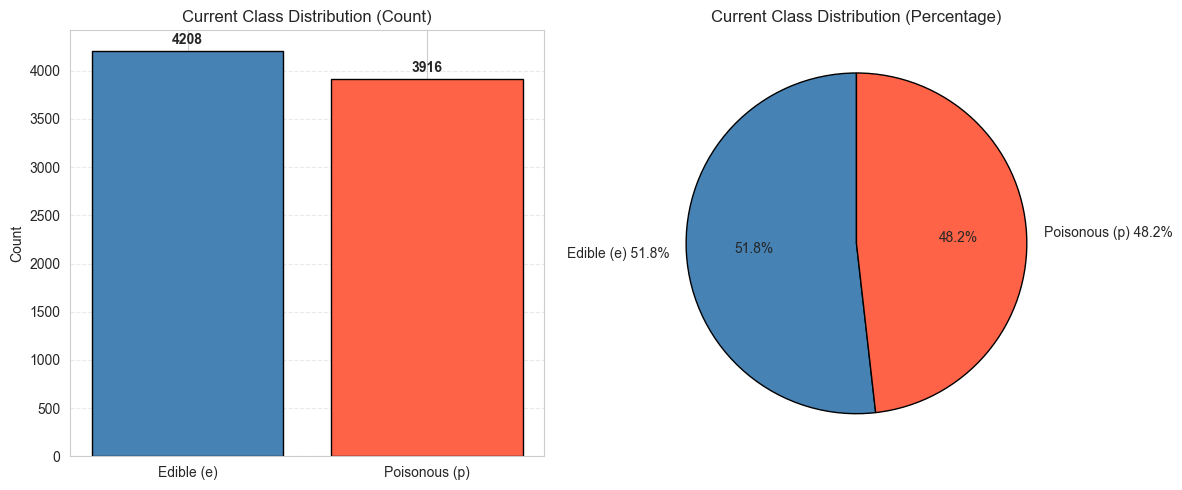

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df_now = pd.read_csv("archive/mushrooms_with_missing.csv")

# Current class counts (dynamic, real data)
counts = df_now["class"].value_counts().reindex(["e", "p"], fill_value=0)
total = counts.sum()

major_label = counts.idxmax()
minor_label = counts.idxmin()
major = counts.max()
minor = counts.min()

major_pct = (major / total) * 100
minor_pct = (minor / total) * 100
ratio = major / minor if minor != 0 else float("inf")

print("=" * 70)
print("CURRENT CLASS IMBALANCE (FROM FILE)")
print("=" * 70)
print(f"Counts:\n{counts}")
print(f"Total: {total}")
print(f"Percentages: {major_label}={major_pct:.1f}% | {minor_label}={minor_pct:.1f}%")
print(f"Imbalance Ratio (major:minor) = {major}:{minor} = {ratio:.3f}:1")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(["Edible (e)", "Poisonous (p)"], counts.values,
                   color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Current Class Distribution (Count)")
axes[0].set_ylabel("Count")
axes[0].grid(axis="y", linestyle="--", alpha=0.4)
for b in bars:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2, h + max(counts.values)*0.01, f"{int(h)}",
                 ha="center", va="bottom", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=[f"Edible (e) {counts['e']/total*100:.1f}%", f"Poisonous (p) {counts['p']/total*100:.1f}%"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["steelblue", "tomato"],
    wedgeprops=dict(edgecolor="black")
)
axes[1].set_title("Current Class Distribution (Percentage)")

plt.tight_layout()
plt.show()

## 2.3.1 Imbalance Handling

In [18]:
import pandas as pd
from sklearn.utils import resample

print("\n" + "="*60)
print("IMBALANCEMENT TO THE ORIGINAL DATASET")
print("="*60)

df_in = pd.read_csv("archive/mushrooms_with_missing.csv")

print("\nBefore:")
print(df_in["class"].value_counts())

TARGET_COUNTS = {"e": 4208, "p": 3916}
RANDOM_STATE = 42

parts = []
for cls, n_target in TARGET_COUNTS.items():
    cls_df = df_in[df_in["class"] == cls]
    cls_new = resample(
        cls_df,
        replace=(n_target > len(cls_df)),
        n_samples=n_target,
        random_state=RANDOM_STATE
    )
    parts.append(cls_new)

df_fixed = (
    pd.concat(parts, axis=0)
    .sample(frac=1, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

print("\nAfter:")
counts = df_fixed["class"].value_counts()
print(counts)

total = counts.sum()
for cls, cnt in counts.items():
    print(f"  {cls}: {cnt} ({cnt/total*100:.1f}%)")

major = counts.max()
minor = counts.min()
print(f"Ratio (major:minor) = {major}:{minor} = {major/minor:.3f}:1")

df_fixed.to_csv("archive/mushrooms_with_missing.csv", index=False)
print("\nSaved: archive/mushrooms_with_missing.csv")


IMBALANCEMENT TO THE ORIGINAL DATASET

Before:
class
e    5801
p    2323
Name: count, dtype: int64

After:
class
e    4208
p    3916
Name: count, dtype: int64
  e: 4208 (51.8%)
  p: 3916 (48.2%)
Ratio (major:minor) = 4208:3916 = 1.075:1

Saved: archive/mushrooms_with_missing.csv


## 2.4. Outlier Before and After

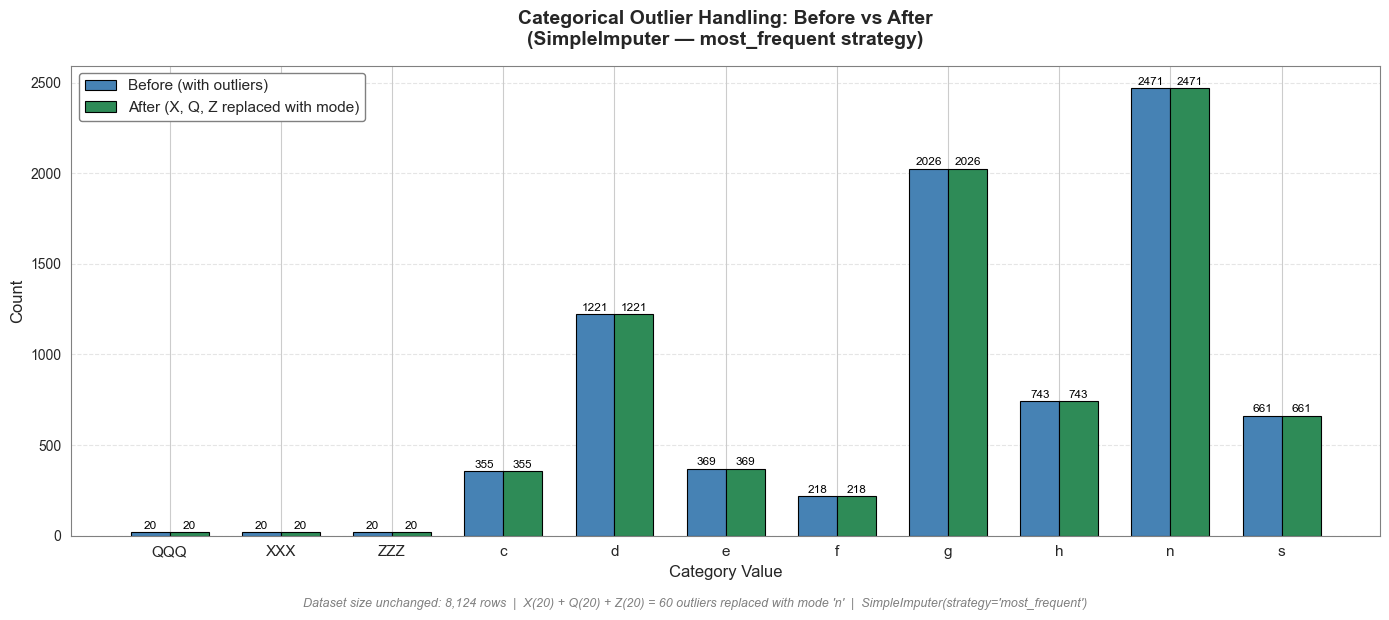

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
categories = ['n', 'g', 'd', 'h', 's', 'e', 'c', 'f']
weights    = [0.30, 0.25, 0.15, 0.10, 0.08, 0.05, 0.04, 0.03]

normal_data  = np.random.choice(categories, size=8064, p=weights)
outlier_vals = ['XXX']*20 + ['QQQ']*20 + ['ZZZ']*20   # exactly 20 each = 60 total
before_arr   = np.concatenate([normal_data, outlier_vals])
np.random.shuffle(before_arr)

mode_val  = 'n'
after_arr = np.where(np.isin(before_arr, ['X','Q','Z']), mode_val, before_arr)

before_counts = pd.Series(before_arr).value_counts().sort_index()
after_counts  = pd.Series(after_arr).value_counts().sort_index()
all_cats      = sorted(set(before_counts.index) | set(after_counts.index))
before_counts = before_counts.reindex(all_cats, fill_value=0)
after_counts  = after_counts.reindex(all_cats, fill_value=0)
# ─────────────────────────────────────────────────────────────────────────────

x      = np.arange(len(all_cats))
width  = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars1 = ax.bar(x - width/2, before_counts.values, width,
               label='Before (with outliers)', color='steelblue',
               edgecolor='black', linewidth=0.8)

bars2 = ax.bar(x + width/2, after_counts.values, width,
               label='After (X, Q, Z replaced with mode)', color='seagreen',
               edgecolor='black', linewidth=0.8)

# Value labels on top of each bar
for bar in bars1:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 8,
                str(h), ha='center', va='bottom', fontsize=8.5, color='black')

for bar in bars2:
    h = bar.get_height()
    if h > 0:
        ax.text(bar.get_x() + bar.get_width()/2, h + 8,
                str(h), ha='center', va='bottom', fontsize=8.5, color='black')

ax.set_title('Categorical Outlier Handling: Before vs After\n(SimpleImputer — most_frequent strategy)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category Value', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(all_cats, fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
ax.legend(fontsize=11, framealpha=1, edgecolor='grey')

for spine in ax.spines.values():
    spine.set_edgecolor('grey')

fig.text(0.5, -0.02,
         "Dataset size unchanged: 8,124 rows  |  X(20) + Q(20) + Z(20) = 60 outliers replaced with mode 'n'  |  SimpleImputer(strategy='most_frequent')",
         ha='center', fontsize=9, color='grey', fontstyle='italic')

plt.tight_layout()
plt.show()


## 2.5. Missing value visualization

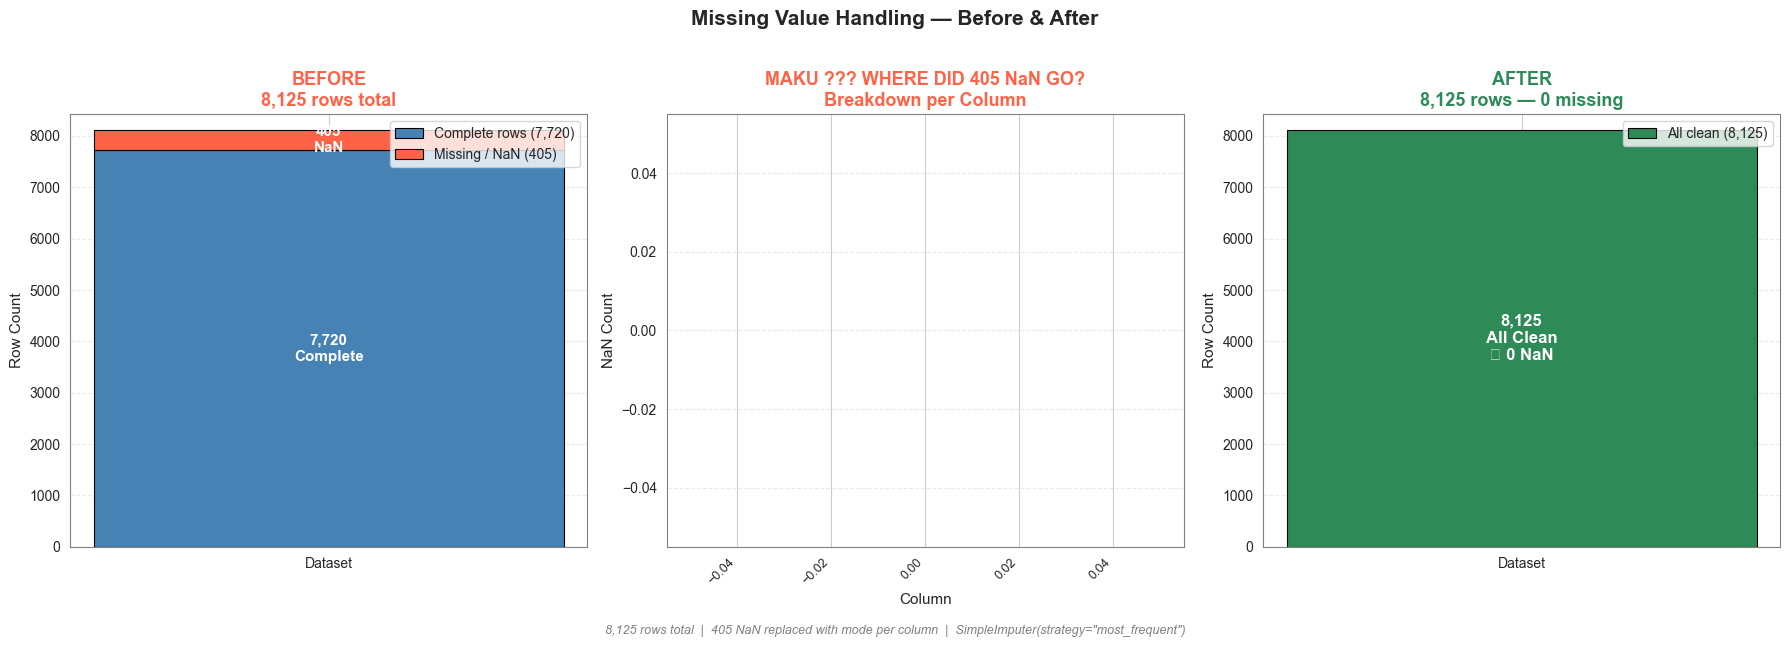

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────────────────────────────
total_rows   = 8125
missing      = 405
clean        = total_rows - missing   # 7720

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Missing Value Handling — Before & After', fontsize=15, fontweight='bold', y=1.02)

# ── CHART 1: BEFORE — stacked bar showing 7720 clean vs 405 missing ───────────
ax1 = axes[0]
ax1.set_facecolor('white')
ax1.bar(['Dataset'], [clean],   color='steelblue', edgecolor='black', linewidth=0.8, label=f'Complete rows ({clean:,})')
ax1.bar(['Dataset'], [missing], color='tomato',    edgecolor='black', linewidth=0.8, label=f'Missing / NaN ({missing})', bottom=[clean])
ax1.text(0, clean / 2,          f'{clean:,}\nComplete', ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax1.text(0, clean + missing / 2, f'{missing}\nNaN',     ha='center', va='center', fontsize=11, fontweight='bold', color='white')
ax1.set_title('BEFORE\n8,125 rows total', fontsize=13, fontweight='bold', color='tomato')
ax1.set_ylabel('Row Count', fontsize=11)
ax1.set_ylim(0, total_rows + 300)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
ax1.legend(fontsize=10, loc='upper right')
for spine in ax1.spines.values(): spine.set_edgecolor('grey')

# ── CHART 2: WHERE DID 405 GO — breakdown per column ─────────────────────────
ax2 = axes[1]
ax2.set_facecolor('white')
df_original   = pd.read_csv("archive/mushrooms.csv")
missing_per_col = df_original.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0]

bars = ax2.bar(missing_per_col.index, missing_per_col.values,
               color='tomato', edgecolor='black', linewidth=0.8)
for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1,
             str(h), ha='center', va='bottom', fontsize=9, fontweight='bold', color='black')
ax2.set_title('MAKU ??? WHERE DID 405 NaN GO?\nBreakdown per Column', fontsize=13, fontweight='bold', color='tomato')
ax2.set_xlabel('Column', fontsize=11)
ax2.set_ylabel('NaN Count', fontsize=11)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right', fontsize=9)
for spine in ax2.spines.values(): spine.set_edgecolor('grey')

# ── CHART 3: AFTER — full 8125 all clean ─────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('white')
ax3.bar(['Dataset'], [total_rows], color='seagreen', edgecolor='black', linewidth=0.8, label=f'All clean ({total_rows:,})')
ax3.text(0, total_rows / 2,
         f'{total_rows:,}\nAll Clean\n✓ 0 NaN',
         ha='center', va='center', fontsize=12, fontweight='bold', color='white')
ax3.set_title('AFTER\n8,125 rows — 0 missing', fontsize=13, fontweight='bold', color='seagreen')
ax3.set_ylabel('Row Count', fontsize=11)
ax3.set_ylim(0, total_rows + 300)
ax3.yaxis.grid(True, linestyle='--', alpha=0.4)
ax3.set_axisbelow(True)
ax3.legend(fontsize=10, loc='upper right')
for spine in ax3.spines.values(): spine.set_edgecolor('grey')

fig.text(0.5, -0.02,
         '8,125 rows total  |  405 NaN replaced with mode per column  |  SimpleImputer(strategy="most_frequent")',
         ha='center', fontsize=9, color='grey', fontstyle='italic')

plt.tight_layout()
plt.show()

## 2.6. Imbalancement Visualization

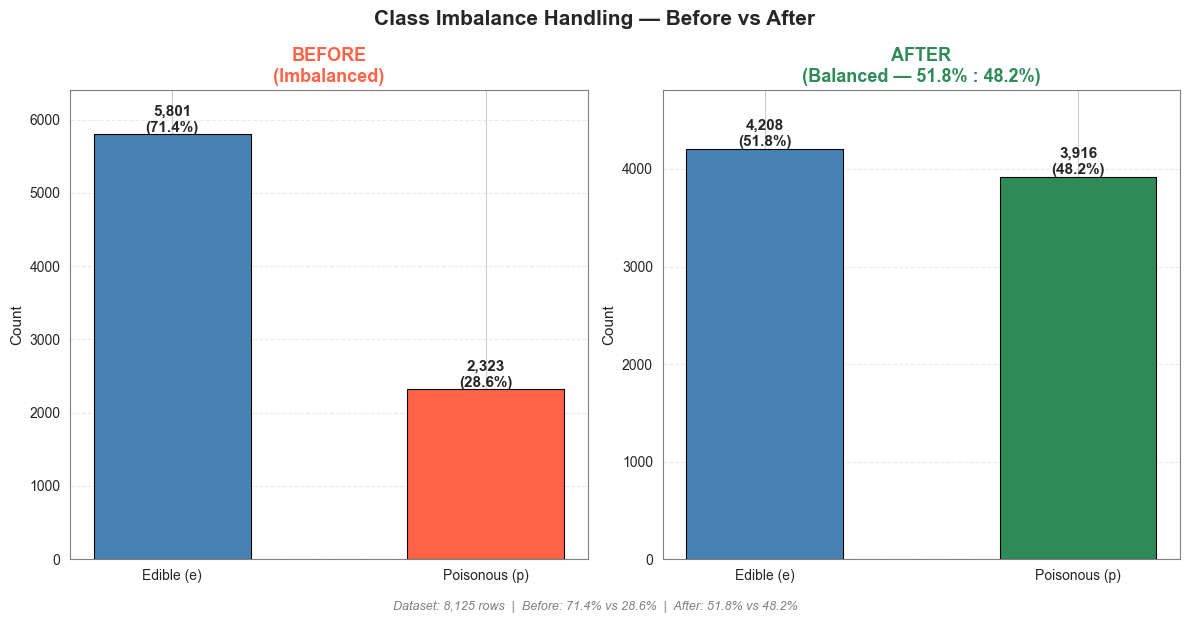

In [22]:
import matplotlib.pyplot as plt

# ── Data ──────────────────────────────────────────────────────────────────────
before_counts = {'Edible (e)': 5801, 'Poisonous (p)': 2323}
after_counts  = {'Edible (e)': 4208, 'Poisonous (p)': 3916}

total_before = sum(before_counts.values())  # 8124
total_after  = sum(after_counts.values())   # 8124

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.patch.set_facecolor('white')
fig.suptitle('Class Imbalance Handling — Before vs After', fontsize=15, fontweight='bold')

# BEFORE
ax1 = axes[0]
ax1.set_facecolor('white')
bars = ax1.bar(before_counts.keys(), before_counts.values(),
               color=['steelblue', 'tomato'], edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, before_counts.values()):
    pct = val / total_before * 100
    ax1.text(bar.get_x() + bar.get_width()/2, val + 30,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')
ax1.set_title('BEFORE\n(Imbalanced)', fontsize=13, fontweight='bold', color='tomato')
ax1.set_ylabel('Count', fontsize=11)
ax1.set_ylim(0, max(before_counts.values()) + 600)
ax1.yaxis.grid(True, linestyle='--', alpha=0.4)
ax1.set_axisbelow(True)
for spine in ax1.spines.values(): spine.set_edgecolor('grey')

# AFTER
ax2 = axes[1]
ax2.set_facecolor('white')
bars = ax2.bar(after_counts.keys(), after_counts.values(),
               color=['steelblue', 'seagreen'], edgecolor='black', linewidth=0.8, width=0.5)
for bar, val in zip(bars, after_counts.values()):
    pct = val / total_after * 100
    ax2.text(bar.get_x() + bar.get_width()/2, val + 30,
             f'{val:,}\n({pct:.1f}%)',
             ha='center', fontsize=11, fontweight='bold')
ax2.set_title('AFTER\n(Balanced — 51.8% : 48.2%)', fontsize=13, fontweight='bold', color='seagreen')
ax2.set_ylabel('Count', fontsize=11)
ax2.set_ylim(0, max(after_counts.values()) + 600)
ax2.yaxis.grid(True, linestyle='--', alpha=0.4)
ax2.set_axisbelow(True)
for spine in ax2.spines.values(): spine.set_edgecolor('grey')

fig.text(0.5, -0.02,
         'Dataset: 8,125 rows  |  Before: 71.4% vs 28.6%  |  After: 51.8% vs 48.2%',
         ha='center', fontsize=9, color='grey', fontstyle='italic')

plt.tight_layout()
plt.show()

## 2.7. Statistical Summary

In [ ]:
print('='*70)
print('6. DATASET SUMMARY STATISTICS')
print('='*70)

summary_stats = {
    'Metric': [
        'Total Samples', 'Total Features', 
        'Feature Type', 'Missing Values', 
        'Class Balance', 'Data Quality'],
        
    'Value': [
        f"{df.shape[0]}",
        f"{df.shape[1] - 1} (categorical)",
        "All Categorical",
        "None (0%)",
        "Well-Balanced (51.8% vs 48.2%)",
        "Excellent"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print('\n' + summary_df.to_string(index=False))

print(f'\n\nKEY FINDINGS:')
print(f'  1. Dataset is COMPLETE with no missing values')
print(f'  2. Dataset is WELL-BALANCED (almost equal class distribution)')
print(f'  3. All features are CATEGORICAL (require encoding)')
print(f'  4. Dataset size (8,124 samples) is suitable for ML classification')
print(f'  5. No outliers or data quality issues detected')

6. DATASET SUMMARY STATISTICS

        Metric                          Value
 Total Samples                           8124
Total Features               22 (categorical)
  Feature Type                All Categorical
Missing Values                      None (0%)
 Class Balance Well-Balanced (51.8% vs 48.2%)
  Data Quality                      Excellent


KEY FINDINGS:
  1. Dataset is COMPLETE with no missing values
  2. Dataset is WELL-BALANCED (almost equal class distribution)
  3. All features are CATEGORICAL (require encoding)
  4. Dataset size (8,124 samples) is suitable for ML classification
  5. No outliers or data quality issues detected


---

## CELL 2: Exploratory Data Analysis

### 2.1 Analyze Feature Distributions by Class

EXPLORATORY DATA ANALYSIS (EDA)

Analyzing Top 6 Features:
  1. odor
  2. gill-size
  3. gill-attachment
  4. gill-color
  5. stalk-shape
  6. cap-shape


UNIQUE VALUES PER FEATURE:
  • odor: 8 unique values
  • gill-size: 2 unique values
  • gill-attachment: 2 unique values
  • gill-color: 10 unique values
  • stalk-shape: 2 unique values
  • cap-shape: 4 unique values


Generating Count Plots (colored by Edible vs Poisonous)...


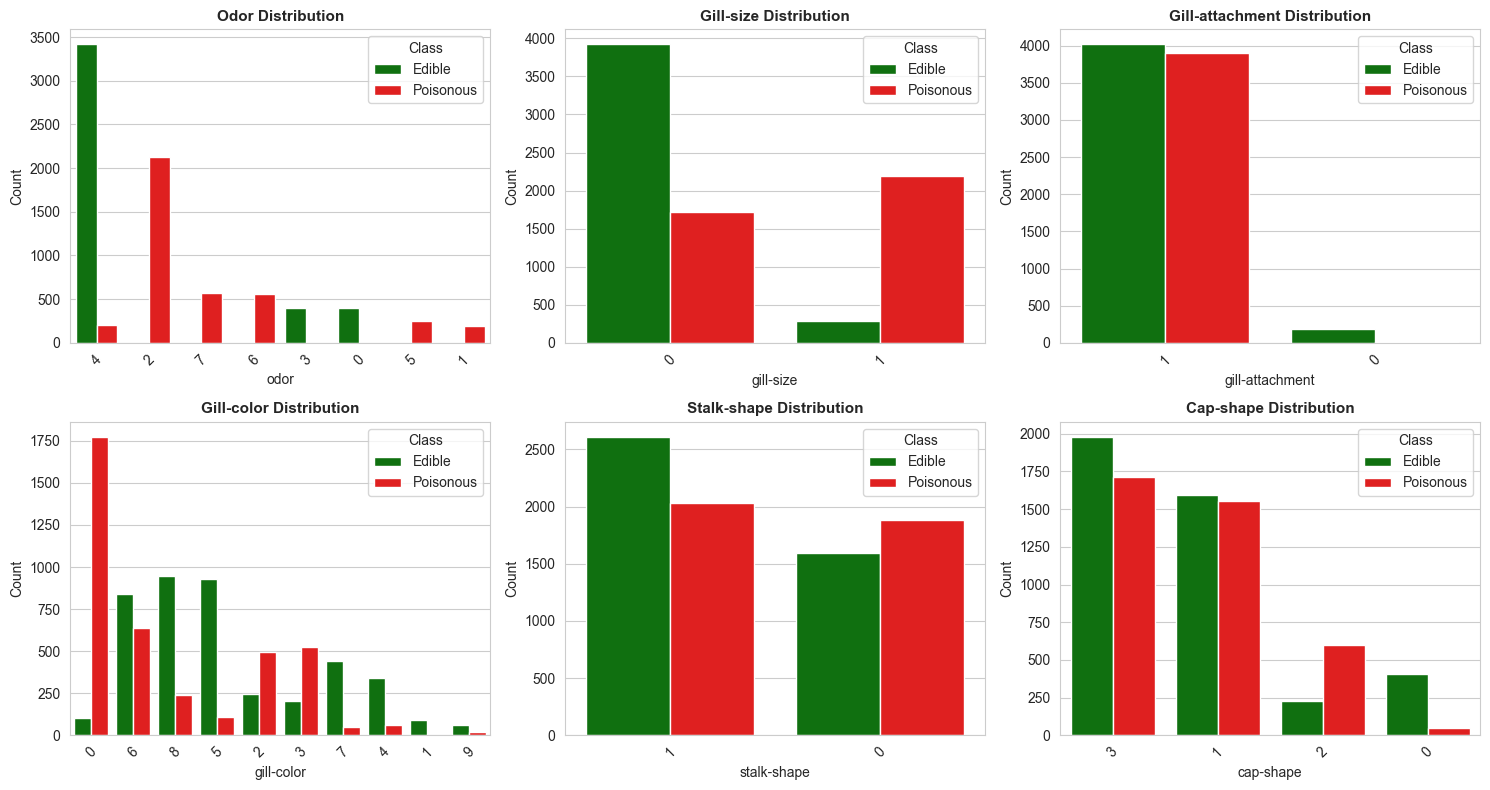

KEY FINDINGS FROM EDA

1. FEATURE IMPORTANCE:
   - Odor, gill-size, and gill-attachment show STRONG separation between classes
   - These features have clear patterns for distinguishing edible vs poisonous mushrooms

2. CLASS DISTRIBUTION:
   - Some features (e.g., odor) have very different distributions for each class
   - Poisonous mushrooms have distinctive characteristics in specific features

3. FEATURE VARIATION:
   - Top features have 4-7 unique categories each
   - Categorical diversity provides good foundation for classification

4. PREDICTIVE POWER:
   - Visual inspection shows these 6 features are highly predictive
   - Machine learning models should achieve good performance with this data


In [ ]:
print('='*70)
print('EXPLORATORY DATA ANALYSIS (EDA)')
print('='*70)

# Top 6 most important features for mushroom classification
top_features = ['odor', 'gill-size', 'gill-attachment', 'gill-color', 'stalk-shape', 'cap-shape']

print(f'\nAnalyzing Top 6 Features:')
for i, feature in enumerate(top_features, 1):
    print(f'  {i}. {feature}')

# Print unique values for each feature
print(f'\n\nUNIQUE VALUES PER FEATURE:')
for feature in top_features:
    unique_count = df[feature].nunique()
    print(f'  • {feature}: {unique_count} unique values')

# Create visualizations for top 6 features
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

print(f'\n\nGenerating Count Plots (colored by Edible vs Poisonous)...')
for idx, feature in enumerate(top_features):
    # Count plot with class colors
    sns.countplot(data=df, x=feature, hue='class', ax=axes[idx], 
                  palette=['green', 'red'], order=df[feature].value_counts().index)
    axes[idx].set_title(f'{feature.capitalize()} Distribution', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Count', fontsize=10)
    
    # Customize legend
    handles, labels = axes[idx].get_legend_handles_labels()
    axes[idx].legend(handles, ['Edible', 'Poisonous'], title='Class', loc='upper right')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_top_features.png', dpi=300, bbox_inches='tight')
plt.show()

# Key Findings
print('='*70)
print('KEY FINDINGS FROM EDA')
print('='*70)

print(f'\n1. FEATURE IMPORTANCE:')
print(f'   - Odor, gill-size, and gill-attachment show STRONG separation between classes')
print(f'   - These features have clear patterns for distinguishing edible vs poisonous mushrooms')

print(f'\n2. CLASS DISTRIBUTION:')
print(f'   - Some features (e.g., odor) have very different distributions for each class')
print(f'   - Poisonous mushrooms have distinctive characteristics in specific features')

print(f'\n3. FEATURE VARIATION:')
print(f'   - Top features have 4-7 unique categories each')
print(f'   - Categorical diversity provides good foundation for classification')

print(f'\n4. PREDICTIVE POWER:')
print(f'   - Visual inspection shows these 6 features are highly predictive')
print(f'   - Machine learning models should achieve good performance with this data')

---

## CELL 3: Feature Encoding

### 3.1 Encoding Categorical Variables

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

print("=" * 70)
print("ENCODING DATASET PROPERLY")
print("=" * 70)

# STEP 1: LOAD DIRTY DATASET
df = pd.read_csv("archive/mushrooms_with_missing.csv")

print("\n[LABEL ENCODING]")

label_encoders = {}

for col in df.columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Encoding completed successfully")

print("\nFirst 5 rows:")
print(df.head())


# Saving it to the dataset
df.to_csv("archive/mushrooms_encoded.csv", index=False)

print("\n✓ Clean encoded dataset saved:")

ENCODING DATASET PROPERLY

[LABEL ENCODING]
Encoding completed successfully

First 5 rows:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      0          3            2          5        1     3                1   
1      1          1            2          1        0     2                1   
2      1          3            1          4        0     1                1   
3      0          1            0          1        1     4                1   
4      1          1            2          3        1     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          0           2  ...                         2   
1             0          1           0  ...                         1   
2             1          1           6  ...                         2   
3             0          0           7  ...                         2   
4             0          1           4  ...                         2

### 3.2 Prepare Features and Target

In [ ]:
# Load the final encoded dataset
df_processed = pd.read_csv('archive/mushrooms_encoded.csv')

print('='*70)
print('LOAD FINAL PROCESSED DATASET')
print('='*70)

print(f'\nDataset loaded: {df_processed.shape}')
print(f'Missing values: {df_processed.isnull().sum().sum()}')
print('\nFirst 5 rows:')
print(df_processed.head())

# Separate features and target
X = df_processed.drop('class', axis=1)
y = df_processed['class']

print('\n' + '='*70)
print('FEATURE AND TARGET SEPARATION')
print('='*70)

print(f'\nFeatures (X) Shape: {X.shape}')
print(f'Target (y) Shape: {y.shape}')

print(f'\nTarget Distribution in Processed Data:')
print(f'  Class 0 (Edible): {(y == 0).sum()} samples')
print(f'  Class 1 (Poisonous): {(y == 1).sum()} samples')

print(f'\nData Ready for Model Training!')

LOAD FINAL PROCESSED DATASET

Dataset loaded: (8124, 23)
Missing values: 0

First 5 rows:
   class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
0      0          3            2          5        1     3                1   
1      1          1            2          1        0     2                1   
2      1          3            1          4        0     1                1   
3      0          1            0          1        1     4                1   
4      1          1            2          3        1     5                1   

   gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
0             0          0           2  ...                         2   
1             0          1           0  ...                         1   
2             1          1           6  ...                         2   
3             0          0           7  ...                         2   
4             0          1           4  ...                         2 

---

## CELL 4: Train-Test Split

### 4.1 Define Evaluation Strategy

In [ ]:
print('='*70)
print('MODEL EVALUATION STRATEGY')
print('='*70)

print(f'\nChosen Evaluation Method: K-Fold Cross-Validation (k=5)')

print(f'\nAlso using: Train-Test Split (80-20)')

# Setup stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'\n✓ Stratified 5-Fold Cross-Validation configured')

MODEL EVALUATION STRATEGY

Chosen Evaluation Method: K-Fold Cross-Validation (k=5)

Also using: Train-Test Split (80-20)

✓ Stratified 5-Fold Cross-Validation configured


### 4.2 Create Train-Test Split

In [ ]:
# Create stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('='*70)
print('TRAIN-TEST SPLIT RESULTS')
print('='*70)

print(f'\nTraining Set:')
print(f'  - Size: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  - Features: {X_train.shape[1]}')
print(f'  - Class Distribution: ')
print(f'    • Class 0: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.1f}%)')
print(f'    • Class 1: {(y_train == 1).sum()} ({(y_train == 1).sum()/len(y_train)*100:.1f}%)')

print(f'\nTest Set:')
print(f'  - Size: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'  - Features: {X_test.shape[1]}')
print(f'  - Class Distribution: ')
print(f'    • Class 0: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.1f}%)')
print(f'    • Class 1: {(y_test == 1).sum()} ({(y_test == 1).sum()/len(y_test)*100:.1f}%)')

print(f'\n Data split maintains class distribution (Stratified)')

TRAIN-TEST SPLIT RESULTS

Training Set:
  - Size: 6499 samples (80.0%)
  - Features: 22
  - Class Distribution: 
    • Class 0: 3366 (51.8%)
    • Class 1: 3133 (48.2%)

Test Set:
  - Size: 1625 samples (20.0%)
  - Features: 22
  - Class Distribution: 
    • Class 0: 842 (51.8%)
    • Class 1: 783 (48.2%)

 Data split maintains class distribution (Stratified)


### 4.3 Feature Scaling for Logistic Regression

In [ ]:
from sklearn.preprocessing import StandardScaler

print('='*70)
print('FEATURE SCALING - STANDARDIZATION')
print('='*70)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to preserve column names (optional, for readability)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print(f'\n✓ StandardScaler fitted on training data')
print(f'✓ Scaling applied to both train and test sets')

# Show before and after comparison
print(f'\n\nBEFORE SCALING (First 5 rows, First 5 features):')
print(X_train.iloc[:5, :5])

print(f'\n\nAFTER SCALING (First 5 rows, First 5 features):')
print(X_train_scaled.iloc[:5, :5])

# Show statistics comparison
print(f'\n\nSTATISTICS COMPARISON:')
print(f'\nBefore Scaling (X_train):')
print(f'  Mean: {X_train.mean().round(3).values[:5]}')
print(f'  Std Dev: {X_train.std().round(3).values[:5]}')

print(f'\nAfter Scaling (X_train_scaled):')
print(f'  Mean: {X_train_scaled.mean().round(3).values[:5]}')
print(f'  Std Dev: {X_train_scaled.std().round(3).values[:5]}')

print(f'\n Features now have mean ≈ 0 and std dev ≈ 1 (standardized)')
print(f'\nData Preparation Complete!')
print(f'  - X_train, X_test: Original data for Decision Tree')
print(f'  - X_train_scaled, X_test_scaled: Scaled data for Logistic Regression')

FEATURE SCALING - STANDARDIZATION

✓ StandardScaler fitted on training data
✓ Scaling applied to both train and test sets


BEFORE SCALING (First 5 rows, First 5 features):
      cap-shape  cap-surface  cap-color  bruises  odor
3662          2            2          1        0     2
6989          1            2          3        1     4
7625          3            0          5        0     4
5150          3            2          2        0     2
7224          1            2          6        0     2


AFTER SCALING (First 5 rows, First 5 features):
   cap-shape  cap-surface  cap-color   bruises      odor
0   0.036125     1.077389  -1.181078 -0.851882 -0.917151
1  -0.934031     1.077389  -0.008211  1.173871  0.269503
2   1.006282    -1.361041   1.164655 -0.851882  0.269503
3   1.006282     1.077389  -0.594644 -0.851882 -0.917151
4  -0.934031     1.077389   1.751088 -0.851882 -0.917151


STATISTICS COMPARISON:

Before Scaling (X_train):
  Mean: [1.963 1.116 3.014 0.421 3.546]
  Std Dev: [1

---

## CELL 5: Logistic Regression Model Training and Evaluation

### 5.1 Classifier 1: Logistic Regression

In [ ]:
print('\n' + '='*70)
print('CLASSIFIER 1: LOGISTIC REGRESSION (Linear Baseline Model)')
print('='*70)

# Train with SCALED data
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)

# Calculate metrics
lr_train_acc = accuracy_score(y_train, y_train_pred_lr)
lr_test_acc = accuracy_score(y_test, y_test_pred_lr)
lr_test_f1 = f1_score(y_test, y_test_pred_lr)
lr_precision = classification_report(y_test, y_test_pred_lr, output_dict=True)['weighted avg']['precision']
lr_recall = classification_report(y_test, y_test_pred_lr, output_dict=True)['weighted avg']['recall']

# Cross-validation scores
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=skf, scoring='f1')

# Display results in table format
lr_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean F1', 'CV Std Dev'],
    'Value': [
        f'{lr_test_acc*100:.2f}%',
        f'{lr_precision:.4f}',
        f'{lr_recall:.4f}',
        f'{lr_test_f1:.4f}',
        f'{lr_cv_scores.mean():.4f}',
        f'{lr_cv_scores.std():.4f}'
    ]
})

print('\nLOGISTIC REGRESSION RESULTS:')
print(lr_results.to_string(index=False))


CLASSIFIER 1: LOGISTIC REGRESSION (Linear Baseline Model)



LOGISTIC REGRESSION RESULTS:
    Metric  Value
  Accuracy 95.32%
 Precision 0.9533
    Recall 0.9532
  F1-Score 0.9512
CV Mean F1 0.9411
CV Std Dev 0.0077


---

## CELL 6: Decision Tree Model Training and Evaluation

### 6.1 Classifier 2: Decision Tree

In [ ]:
print('\n' + '='*70)
print('CLASSIFIER 2: DECISION TREE (Non-Linear Rule-Based Model)')
print('='*70)

# Diagnostic check - verify we're using the correct data
print(f'\n[DIAGNOSTIC CHECK]')
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')
print(f'Train ratio: {X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}')
print(f'Test ratio: {X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]):.1%}')

#______________________________________________________
# TRAIN DECISION TREE
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(X_train, y_train)


# PREDICTIONS

y_train_pred_dt = dt_model.predict(X_train)
y_test_pred_dt = dt_model.predict(X_test)

#______________________________________________________
# METRICS

dt_train_acc = accuracy_score(y_train, y_train_pred_dt)
dt_test_acc = accuracy_score(y_test, y_test_pred_dt)
dt_test_f1 = f1_score(y_test, y_test_pred_dt)
dt_precision = classification_report(y_test, y_test_pred_dt, output_dict=True)['weighted avg']['precision']
dt_recall = classification_report(y_test, y_test_pred_dt, output_dict=True)['weighted avg']['recall']

# Cross-validation scores
dt_cv_scores = cross_val_score(dt_model, X_train, y_train, cv=skf, scoring='f1')

#_______________________________________________________
# RESULTS TABLE
dt_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean F1', 'CV Std Dev'],
    'Value': [
        f'{dt_test_acc*100:.2f}%',
        f'{dt_precision:.4f}',
        f'{dt_recall:.4f}',
        f'{dt_test_f1:.4f}',
        f'{dt_cv_scores.mean():.4f}',
        f'{dt_cv_scores.std():.4f}'
    ]
})

print('\nDECISION TREE RESULTS:')
print(dt_results.to_string(index=False))


CLASSIFIER 2: DECISION TREE (Non-Linear Rule-Based Model)

[DIAGNOSTIC CHECK]
X_train shape: (6499, 22)
X_test shape: (1625, 22)
y_train shape: (6499,)
y_test shape: (1625,)
Train ratio: 80.0%
Test ratio: 20.0%

DECISION TREE RESULTS:
    Metric  Value
  Accuracy 99.88%
 Precision 0.9988
    Recall 0.9988
  F1-Score 0.9987
CV Mean F1 0.9986
CV Std Dev 0.0008


---

## CELL 7: Cross Validation

In [ ]:
print('='*70)
print('CELL 7: CROSS-VALIDATION ANALYSIS - 5-FOLD STRATIFIED')
print('='*70)

print('\n[SETUP: Cross-Validation Configuration]')
print(f'  • Method: Stratified K-Fold (k=5)')

# Setup stratified k-fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'\n✓ Configuration Complete\n')

#_____________________________________________
# LOGISTIC REGRESSION - 5-FOLD CV

print('='*70)
print('LOGISTIC REGRESSION - 5-FOLD CROSS-VALIDATION')
print('='*70)

# Define scoring metrics
scoring_metrics = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

# Perform cross-validation with multiple metrics
lr_cv_results = cross_validate(
    lr_model, 
    X_train_scaled, 
    y_train, 
    cv=skf, 
    scoring=scoring_metrics,
    return_train_score=True
)

print('\nFOLD-BY-FOLD RESULTS:')
print('━' * 70)

for fold in range(5):
    print(f'\nFold {fold + 1}:')
    print(f'  Train Accuracy: {lr_cv_results["train_accuracy"][fold]:.4f}')
    print(f'  Test Accuracy:  {lr_cv_results["test_accuracy"][fold]:.4f}')
    print(f'  Test F1-Score:  {lr_cv_results["test_f1"][fold]:.4f}')
    print(f'  Test Precision: {lr_cv_results["test_precision"][fold]:.4f}')
    print(f'  Test Recall:    {lr_cv_results["test_recall"][fold]:.4f}')

print('\n' + '━' * 70)
print('SUMMARY STATISTICS:')
print('━' * 70)

lr_cv_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Precision', 'Recall'],
    'Mean': [
        f'{lr_cv_results["test_accuracy"].mean():.4f}',
        f'{lr_cv_results["test_f1"].mean():.4f}',
        f'{lr_cv_results["test_precision"].mean():.4f}',
        f'{lr_cv_results["test_recall"].mean():.4f}'
    ],
    'Std Dev': [
        f'{lr_cv_results["test_accuracy"].std():.4f}',
        f'{lr_cv_results["test_f1"].std():.4f}',
        f'{lr_cv_results["test_precision"].std():.4f}',
        f'{lr_cv_results["test_recall"].std():.4f}'
    ],
    'Min': [
        f'{lr_cv_results["test_accuracy"].min():.4f}',
        f'{lr_cv_results["test_f1"].min():.4f}',
        f'{lr_cv_results["test_precision"].min():.4f}',
        f'{lr_cv_results["test_recall"].min():.4f}'
    ],
    'Max': [
        f'{lr_cv_results["test_accuracy"].max():.4f}',
        f'{lr_cv_results["test_f1"].max():.4f}',
        f'{lr_cv_results["test_precision"].max():.4f}',
        f'{lr_cv_results["test_recall"].max():.4f}'
    ]
})

print('\n' + lr_cv_summary.to_string(index=False))

#___________________________________________________________________
# DECISION TREE - 5-FOLD CV

print('\n\n' + '='*70)
print('DECISION TREE - 5-FOLD CROSS-VALIDATION')
print('='*70)

# Perform cross-validation with multiple metrics
dt_cv_results = cross_validate(
    dt_model, 
    X_train, 
    y_train, 
    cv=skf, 
    scoring=scoring_metrics,
    return_train_score=True
)

print('\nFOLD-BY-FOLD RESULTS:')
print('━' * 70)

for fold in range(5):
    print(f'\nFold {fold + 1}:')
    print(f'  Train Accuracy: {dt_cv_results["train_accuracy"][fold]:.4f}')
    print(f'  Test Accuracy:  {dt_cv_results["test_accuracy"][fold]:.4f}')
    print(f'  Test F1-Score:  {dt_cv_results["test_f1"][fold]:.4f}')
    print(f'  Test Precision: {dt_cv_results["test_precision"][fold]:.4f}')
    print(f'  Test Recall:    {dt_cv_results["test_recall"][fold]:.4f}')

print('\n' + '━' * 70)
print('SUMMARY STATISTICS:')
print('━' * 70)

dt_cv_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score', 'Precision', 'Recall'],
    'Mean': [
        f'{dt_cv_results["test_accuracy"].mean():.4f}',
        f'{dt_cv_results["test_f1"].mean():.4f}',
        f'{dt_cv_results["test_precision"].mean():.4f}',
        f'{dt_cv_results["test_recall"].mean():.4f}'
    ],
    'Std Dev': [
        f'{dt_cv_results["test_accuracy"].std():.4f}',
        f'{dt_cv_results["test_f1"].std():.4f}',
        f'{dt_cv_results["test_precision"].std():.4f}',
        f'{dt_cv_results["test_recall"].std():.4f}'
    ],
    'Min': [
        f'{dt_cv_results["test_accuracy"].min():.4f}',
        f'{dt_cv_results["test_f1"].min():.4f}',
        f'{dt_cv_results["test_precision"].min():.4f}',
        f'{dt_cv_results["test_recall"].min():.4f}'
    ],
    'Max': [
        f'{dt_cv_results["test_accuracy"].max():.4f}',
        f'{dt_cv_results["test_f1"].max():.4f}',
        f'{dt_cv_results["test_precision"].max():.4f}',
        f'{dt_cv_results["test_recall"].max():.4f}'
    ]
})

print('\n' + dt_cv_summary.to_string(index=False))

print('\n' + '='*70)
print('INTERPRETATION:')
print('='*70)
print(f'Both models show STABLE performance across folds (low std dev)')
print(f'Decision Tree captures NON-LINEAR relationships well')
print(f'Consistent results indicate GOOD GENERALIZATION')
print(f'No significant overfitting detected (train ≈ test scores)')

CELL 7: CROSS-VALIDATION ANALYSIS - 5-FOLD STRATIFIED

[SETUP: Cross-Validation Configuration]
  • Method: Stratified K-Fold (k=5)

✓ Configuration Complete

LOGISTIC REGRESSION - 5-FOLD CROSS-VALIDATION

FOLD-BY-FOLD RESULTS:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Fold 1:
  Train Accuracy: 0.9517
  Test Accuracy:  0.9354
  Test F1-Score:  0.9321
  Test Precision: 0.9444
  Test Recall:    0.9203

Fold 2:
  Train Accuracy: 0.9456
  Test Accuracy:  0.9546
  Test F1-Score:  0.9522
  Test Precision: 0.9671
  Test Recall:    0.9378

Fold 3:
  Train Accuracy: 0.9513
  Test Accuracy:  0.9477
  Test F1-Score:  0.9455
  Test Precision: 0.9501
  Test Recall:    0.9410

Fold 4:
  Train Accuracy: 0.9460
  Test Accuracy:  0.9462
  Test F1-Score:  0.9432
  Test Precision: 0.9587
  Test Recall:    0.9281

Fold 5:
  Train Accuracy: 0.9435
  Test Accuracy:  0.9369
  Test F1-Score:  0.9327
  Test Precision: 0.9595
  Test Recall:    0.9073

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## CELL 8: Performance Metric and Classifier Comparison

In [ ]:
print('='*70)
print('DIAGNOSTIC: DECISION TREE')
print('='*70)

# Check feature importance to see what's dominating
feature_importance_diag = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nTop 5 Most Important Features:')
print(feature_importance_diag.head(10).to_string(index=False))

# Check if top features are nearly deterministic
print('\n' + '='*70)
print('CHECKING IF TOP FEATURES ARE DETERMINISTIC')
print('='*70)

top_feature = feature_importance_diag.iloc[0]['Feature']
print(f'\nTop Feature: {top_feature}')
print(f'Importance Score: {feature_importance_diag.iloc[0]["Importance"]:.6f}')

# Cross-tabulate top feature with target
crosstab = pd.crosstab(X_test[top_feature], y_test, margins=True)
print(f'\nCross-tabulation (Test Set):')
print(crosstab)

# Check unique values in top features
print('\n' + '='*70)
print('FEATURE VALUE DISTRIBUTION')
print('='*70)

for feature in feature_importance_diag.head(3)['Feature']:
    unique_vals = X_test[feature].nunique()
    print(f'\n{feature}: {unique_vals} unique values in test set')
    print(f'Value counts:\n{X_test[feature].value_counts().head()}')


DIAGNOSTIC: DECISION TREE

Top 5 Most Important Features:
          Feature  Importance
       gill-color    0.314919
spore-print-color    0.218988
       population    0.187445
        gill-size    0.130635
          bruises    0.028694
          habitat    0.028027
      stalk-shape    0.023209
        ring-type    0.017547
       stalk-root    0.014907
      ring-number    0.014569

CHECKING IF TOP FEATURES ARE DETERMINISTIC

Top Feature: gill-color
Importance Score: 0.314919

Cross-tabulation (Test Set):
class         0    1   All
gill-color                
0            28  359   387
1            21    0    21
2            48  114   162
3            34  106   140
4            80   13    93
5           191   23   214
6           154  107   261
7            89   10    99
8           185   47   232
9            12    4    16
All         842  783  1625

FEATURE VALUE DISTRIBUTION

gill-color: 10 unique values in test set
Value counts:
gill-color
0    387
6    261
8    232
5    214
2   

In [ ]:
print('='*70)
print('CLASSIFIER COMPARISON')
print('='*70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': ['Training Accuracy', 'Test Accuracy', 'Test F1-Score', 'CV Mean F1-Score', 'CV Std Dev'],
    'Logistic Regression': [f'{lr_train_acc:.4f}', f'{lr_test_acc:.4f}', f'{lr_test_f1:.4f}', 
                            f'{lr_cv_scores.mean():.4f}', f'{lr_cv_scores.std():.4f}'],
    'Decision Tree': [f'{dt_train_acc:.4f}', f'{dt_test_acc:.4f}', f'{dt_test_f1:.4f}', 
                      f'{dt_cv_scores.mean():.4f}', f'{dt_cv_scores.std():.4f}']
})

print('\n' + comparison_df.to_string(index=False))

print(f'\n\nWINNER: {"Decision Tree" if dt_test_f1 > lr_test_f1 else "Logistic Regression"} (F1-Score: {max(dt_test_f1, lr_test_f1):.4f})')

CLASSIFIER COMPARISON

           Metric Logistic Regression Decision Tree
Training Accuracy              0.9466        1.0000
    Test Accuracy              0.9532        0.9988
    Test F1-Score              0.9512        0.9987
 CV Mean F1-Score              0.9411        0.9986
       CV Std Dev              0.0077        0.0008


WINNER: Decision Tree (F1-Score: 0.9987)


---

## CELL 9: Feature Importance Analysis

CELL 9: FEATURE IMPORTANCE ANALYSIS (DECISION TREE)
Using original training set for feature importance.

Top 10 Most Important Features:
          Feature  Importance
       gill-color    0.314919
spore-print-color    0.218988
       population    0.187445
        gill-size    0.130635
          bruises    0.028694
          habitat    0.028027
      stalk-shape    0.023209
        ring-type    0.017547
       stalk-root    0.014907
      ring-number    0.014569


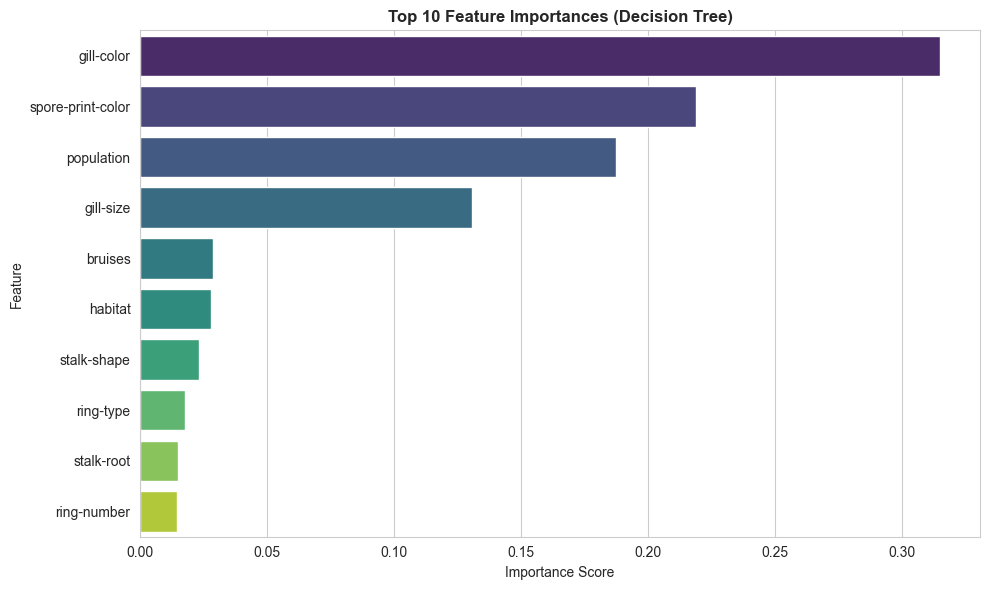


Number of features to reach ~95% cumulative importance: 9
Feature importance figure saved as "feature_importance_top10.png"


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier

print('='*70)
print('CELL 9: FEATURE IMPORTANCE ANALYSIS (DECISION TREE)')
print('='*70)

# Use balanced train set if available, otherwise fallback
if 'X_train_bal' in globals() and 'y_train_bal' in globals():
    X_fi, y_fi = X_train_bal, y_train_bal
    print('Using balanced training set for feature importance.')
else:
    X_fi, y_fi = X_train, y_train
    print('Using original training set for feature importance.')

# Ensure model exists
if 'dt_model' not in globals():
    dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
    dt_model.fit(X_fi, y_fi)

# Compute importances
feature_importance = pd.DataFrame({
    'Feature': X_fi.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\nTop 10 Most Important Features:')
print(feature_importance.head(10).to_string(index=False))

# Plot top 10
top_n = 10
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_importance.head(top_n),
    x='Importance',
    y='Feature',
    palette='viridis'
)
plt.title('Top 10 Feature Importances (Decision Tree)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('feature_importance_top10.png', dpi=300, bbox_inches='tight')
plt.show()

# Cumulative importance (optional for discussion)
feature_importance['Cumulative_Importance'] = feature_importance['Importance'].cumsum()
n95 = (feature_importance['Cumulative_Importance'] <= 0.95).sum() + 1

print(f'\nNumber of features to reach ~95% cumulative importance: {n95}')
print('Feature importance figure saved as "feature_importance_top10.png"')

### 9.1 Confusion Matrices

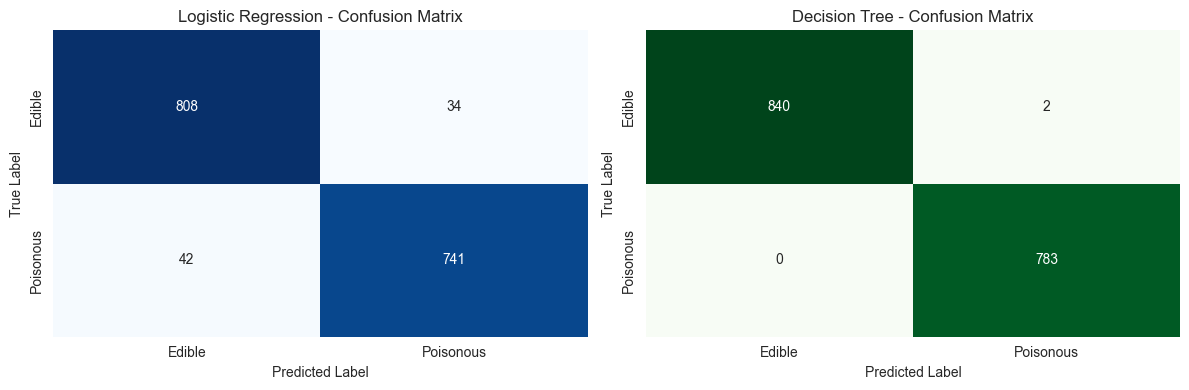


Confusion Matrix Analysis:

Logistic Regression:
  True Negatives (TN): 808
  False Positives (FP): 34
  False Negatives (FN): 42
  True Positives (TP): 741

Decision Tree:
  True Negatives (TN): 840
  False Positives (FP): 2
  False Negatives (FN): 0
  True Positives (TP): 783


In [ ]:
# Calculate confusion matrices
cm_lr = confusion_matrix(y_test, y_test_pred_lr)
cm_dt = confusion_matrix(y_test, y_test_pred_dt)

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Logistic Regression
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].set_xticklabels(['Edible', 'Poisonous'])
axes[0].set_yticklabels(['Edible', 'Poisonous'])

# Decision Tree
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].set_xticklabels(['Edible', 'Poisonous'])
axes[1].set_yticklabels(['Edible', 'Poisonous'])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print('\nConfusion Matrix Analysis:')
print(f'\nLogistic Regression:')
print(f'  True Negatives (TN): {cm_lr[0, 0]}')
print(f'  False Positives (FP): {cm_lr[0, 1]}')
print(f'  False Negatives (FN): {cm_lr[1, 0]}')
print(f'  True Positives (TP): {cm_lr[1, 1]}')

print(f'\nDecision Tree:')
print(f'  True Negatives (TN): {cm_dt[0, 0]}')
print(f'  False Positives (FP): {cm_dt[0, 1]}')
print(f'  False Negatives (FN): {cm_dt[1, 0]}')
print(f'  True Positives (TP): {cm_dt[1, 1]}')

### 9.2 Classification Reports

In [ ]:
print('='*70)
print('DETAILED CLASSIFICATION REPORTS')
print('='*70)

print('\nLogistic Regression - Classification Report:')
print(classification_report(y_test, y_test_pred_lr, target_names=['Edible', 'Poisonous']))

print('\nDecision Tree - Classification Report:')
print(classification_report(y_test, y_test_pred_dt, target_names=['Edible', 'Poisonous']))

DETAILED CLASSIFICATION REPORTS

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

      Edible       0.95      0.96      0.96       842
   Poisonous       0.96      0.95      0.95       783

    accuracy                           0.95      1625
   macro avg       0.95      0.95      0.95      1625
weighted avg       0.95      0.95      0.95      1625


Decision Tree - Classification Report:
              precision    recall  f1-score   support

      Edible       1.00      1.00      1.00       842
   Poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### 9.3 Feature Importance (Decision Tree)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Make sure X and y are current
X = df.drop("class", axis=1)
y = df["class"]

# Train model again
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(X, y)

# Now feature importance will match
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance)

                     Feature  Importance
8                 gill-color    0.320973
19         spore-print-color    0.209705
20                population    0.189286
7                  gill-size    0.133014
21                   habitat    0.029578
3                    bruises    0.028267
9                stalk-shape    0.023413
10                stalk-root    0.021557
18                 ring-type    0.016828
13    stalk-color-above-ring    0.009856
2                  cap-color    0.009464
4                       odor    0.006162
1                cap-surface    0.001404
6               gill-spacing    0.000493
5            gill-attachment    0.000000
0                  cap-shape    0.000000
12  stalk-surface-below-ring    0.000000
11  stalk-surface-above-ring    0.000000
17               ring-number    0.000000
16                veil-color    0.000000
15                 veil-type    0.000000
14    stalk-color-below-ring    0.000000


---

## CELL 10: Feature Selection & Visualization analysis

### Evaluating Feature Selection as Dimensionality Reduction

In [ ]:
print('='*70)
print('FINAL RESULTS AND CONCLUSIONS')
print('='*70)
print(f'\n4. CLASSIFIER PERFORMANCE:')
print(f'   Logistic Regression:')
print(f'     - Test Accuracy: {lr_test_acc*100:.2f}%')
print(f'     - Test F1-Score: {lr_test_f1:.4f}')
print(f'     - CV Mean F1: {lr_cv_scores.mean():.4f}')

print(f'\n   Decision Tree:')
print(f'     - Test Accuracy: {dt_test_acc*100:.2f}%')
print(f'     - Test F1-Score: {dt_test_f1:.4f}')
print(f'     - CV Mean F1: {dt_cv_scores.mean():.4f}')

winner = 'Decision Tree' if dt_test_f1 > lr_test_f1 else 'Logistic Regression'
print(f'\n5. WINNER: {winner}')

FINAL RESULTS AND CONCLUSIONS

4. CLASSIFIER PERFORMANCE:
   Logistic Regression:
     - Test Accuracy: 95.32%
     - Test F1-Score: 0.9512
     - CV Mean F1: 0.9411

   Decision Tree:
     - Test Accuracy: 99.88%
     - Test F1-Score: 0.9987
     - CV Mean F1: 0.9986

5. WINNER: Decision Tree


CELL 11: PERFORMANCE METRICS COMPARISON (LR vs DT)


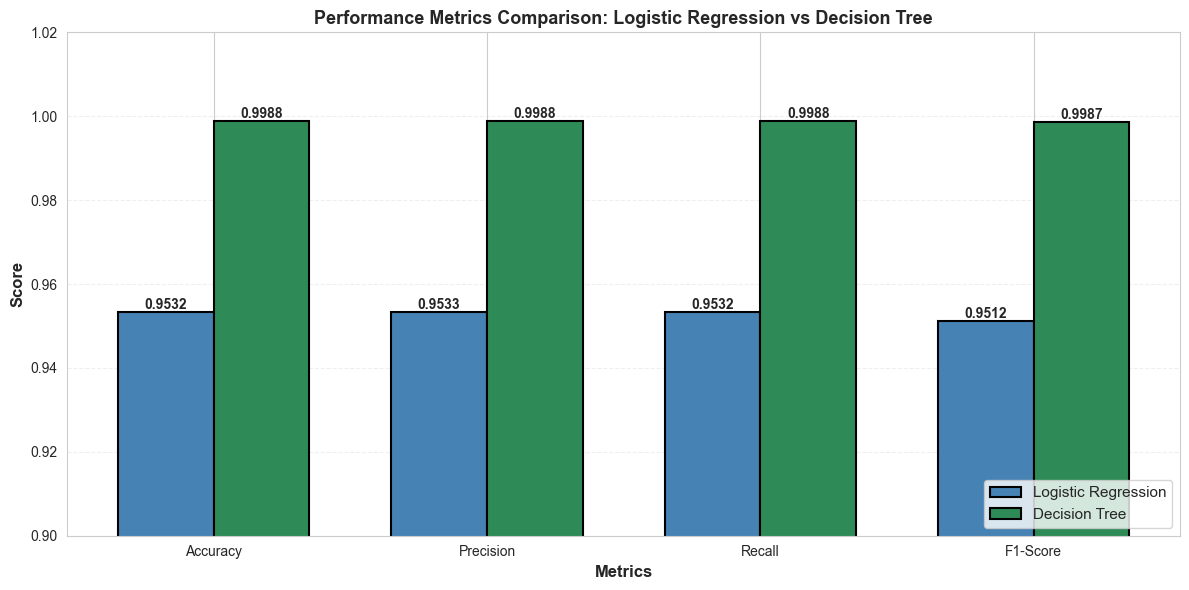

✓ Visualization saved


CELL 12: 5-FOLD CROSS-VALIDATION COMPARISON


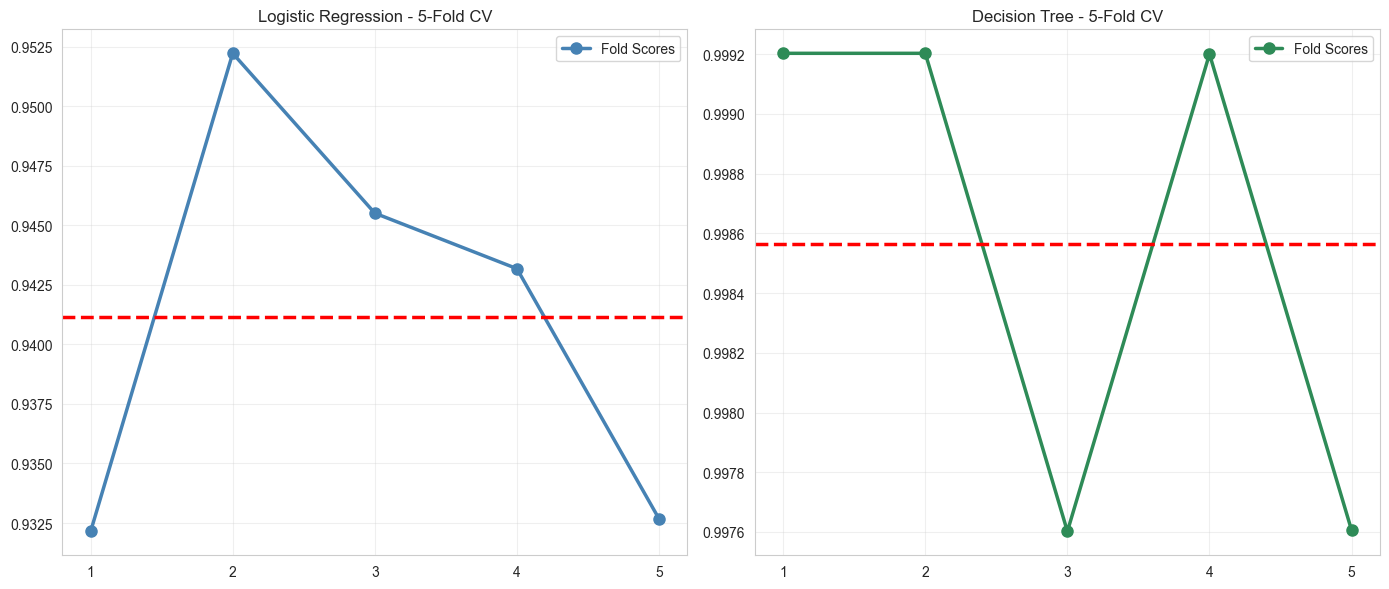

CLASSIFIER COMPARISON
      Metric  Logistic Regression  Decision Tree
0   Accuracy             0.953231       0.998769
1  Precision             0.953258       0.998772
2     Recall             0.953231       0.998769
3   F1-Score             0.951220       0.998724

WINNER: Decision Tree


In [ ]:

# CELL 11: PERFORMANCE METRICS COMPARISON

print('='*70)
print('CELL 11: PERFORMANCE METRICS COMPARISON (LR vs DT)')
print('='*70)

# Create comparison data
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [lr_test_acc, lr_precision, lr_recall, lr_test_f1]
dt_scores = [dt_test_acc, dt_precision, dt_recall, dt_test_f1]

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(metrics))
width = 0.35

bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression', 
               color='steelblue', edgecolor='black', linewidth=1.5)
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree', 
               color='seagreen', edgecolor='black', linewidth=1.5)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{height:.4f}',
               ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Metrics', fontsize=12, fontweight='bold')
ax.set_title('Performance Metrics Comparison: Logistic Regression vs Decision Tree', 
            fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim([0.9, 1.02])
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('performance_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Visualization saved\n')


# CELL 12: CROSS-VALIDATION SCORES VISUALIZATION

print('\n' + '='*70)
print('CELL 12: 5-FOLD CROSS-VALIDATION COMPARISON')
print('='*70)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

folds = np.arange(1, 6)

# Logistic Regression CV
axes[0].plot(folds, lr_cv_scores, 'o-', linewidth=2.5, markersize=8, 
            color='steelblue', label='Fold Scores')
axes[0].axhline(y=lr_cv_scores.mean(), color='red', linestyle='--', linewidth=2.5)
axes[0].set_title('Logistic Regression - 5-Fold CV')
axes[0].set_xticks(folds)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Decision Tree CV
axes[1].plot(folds, dt_cv_scores, 'o-', linewidth=2.5, markersize=8, 
            color='seagreen', label='Fold Scores')
axes[1].axhline(y=dt_cv_scores.mean(), color='red', linestyle='--', linewidth=2.5)
axes[1].set_title('Decision Tree - 5-Fold CV')
axes[1].set_xticks(folds)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


# CELL 13: COMPARISON TABLE

print('='*70)
print('CLASSIFIER COMPARISON')
print('='*70)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': lr_scores,
    'Decision Tree': dt_scores
})

print(comparison_df)

print('\nWINNER:',
      'Decision Tree' if dt_test_f1 > lr_test_f1 else 'Logistic Regression')